# Targeted Attack + Clean-Basis SVD Vaccination by Score Tier

**Purpose:** Same experiment as targeted_vaccination_by_tier.ipynb, but the SVD basis is
precomputed from clean data

In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR = Path('spambase_10_40_50')
SCORES_DIR = Path('noise_scoring_outputs/20260324_203954')
PREV_RESULTS_DIR = Path('targeted_vaccination_results_10_40_50')
OUTPUT_DIR = Path('targeted_vaccination_clean_basis_results_deepfool')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.001
MAXITERS = 300
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]


Device: cuda
GPU: NVIDIA RTX A6000


## 1. Load Data, Model, and Noise Scores

In [8]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_train = data['X_train'].astype(np.float32)
n_svd_basis_rows = int(data['X_svd'].shape[0])
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Train set: {X_train.shape[0]} samples, {n_features} features')
print(f'SVD basis partition: {n_svd_basis_rows} samples (see clean_svd_basis.npz)')
print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

Train set: 1840 samples, 57 features
SVD basis partition: 460 samples (see clean_svd_basis.npz)
Test set: 2301 samples, 57 features
Correctly classified: 2058/2301 (89.44%)


In [6]:
score1_removal_order = np.load('experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load('experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score2_noise_scores.npy')

score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2057


## 2. Load Clean-Basis SVD (10% holdout partition)


`Vt_clean` from `clean_svd_basis.npz` (SVD on 460 rows), saved by `spambase_resplit_setup.ipynb`._

In [9]:
svd_basis = np.load(DATA_DIR / 'clean_svd_basis.npz')
Vt_clean = svd_basis['Vt_svd'].astype(np.float32)
S_clean = svd_basis['S_svd']
print(f'Clean basis shape: Vt_clean = {Vt_clean.shape} (SVD rows = {n_svd_basis_rows})')
print(f'Top-10 singular values: {S_clean[:10].round(2)}')
print(f'Cumulative energy at each k:')
cumvar = np.cumsum(S_clean**2) / np.sum(S_clean**2)
for k in K_RANKS:
    print(f'  k={k:>2d}: {cumvar[k-1]:.4f}')

Clean basis shape: Vt_clean = (57, 57) (SVD rows = 460)
Top-10 singular values: [4.76 3.28 2.39 2.28 2.13 2.06 2.05 1.96 1.89 1.7 ]
Cumulative energy at each k:
  k= 1: 0.2283
  k= 2: 0.3370
  k= 3: 0.3946
  k= 5: 0.4927
  k=10: 0.6813
  k=15: 0.7888
  k=20: 0.8536
  k=30: 0.9440
  k=40: 0.9813
  k=50: 0.9980
  k=57: 1.0000


## 3. Load Adversarial Samples

In [10]:
adv_file = PREV_RESULTS_DIR / 'adversarial_samples.npz'
assert adv_file.exists(), f'Run targeted_vaccination_by_tier_deepfool.ipynb first to generate {adv_file}'

adv_data = np.load(adv_file)
X_adv = adv_data['X_adv_deepfool']
attack_success = adv_data['success_deepfool']

n_succ = attack_success[correct_indices].sum()
print(f'DeepFool: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')


DeepFool: 2058/2058 (100.00%) attacks succeeded


## 4. Clean-Basis Vaccination Sweep

In [11]:
rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        noisy_indices = order[:n_attack]
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            X_mixed = np.copy(X_test)
            n_successfully_attacked = 0
            for idx in tier_idx:
                if attack_success[idx]:
                    X_mixed[idx] = X_adv[idx]
                    n_successfully_attacked += 1

            if n_successfully_attacked == 0:
                for k in K_RANKS:
                    rows.append({
                        'score_type': score_name, 'tier': tier_name,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': 0,
                        'restoration_rate': 0.0, 'asr_after': 0.0,
                    })
                continue

            for k in K_RANKS:
                # Project onto precomputed clean basis instead of computing SVD on X_mixed
                Vk = Vt_clean[:k, :]  # (k, 57)
                X_vacc = (X_mixed @ Vk.T) @ Vk  # project and reconstruct
                X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)

                with torch.no_grad():
                    preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                n_restored = sum(
                    1 for idx in tier_idx
                    if attack_success[idx] and preds[idx] == y_test[idx]
                )
                restoration_rate = n_restored / n_successfully_attacked

                rows.append({
                    'score_type': score_name, 'tier': tier_name,
                    'attack_pct': attack_pct, 'k': k,
                    'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                    'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')


Score 1 | attack_pct= 10% done (0.0s)
Score 1 | attack_pct= 20% done (0.0s)
Score 1 | attack_pct= 30% done (0.1s)
Score 1 | attack_pct= 40% done (0.1s)
Score 1 | attack_pct= 50% done (0.1s)
Score 1 | attack_pct= 60% done (0.1s)
Score 1 | attack_pct= 70% done (0.2s)
Score 1 | attack_pct= 80% done (0.2s)
Score 1 | attack_pct= 90% done (0.2s)
Score 1 | attack_pct=100% done (0.2s)
Score 2 | attack_pct= 10% done (0.3s)
Score 2 | attack_pct= 20% done (0.3s)
Score 2 | attack_pct= 30% done (0.3s)
Score 2 | attack_pct= 40% done (0.3s)
Score 2 | attack_pct= 50% done (0.3s)
Score 2 | attack_pct= 60% done (0.4s)
Score 2 | attack_pct= 70% done (0.4s)
Score 2 | attack_pct= 80% done (0.4s)
Score 2 | attack_pct= 90% done (0.5s)
Score 2 | attack_pct=100% done (0.5s)

Sweep complete: 440 rows, saved to targeted_vaccination_clean_basis_results_deepfool/vaccination_sweep.csv


## 5. Heatmaps

Saved vaccination_clean_score1_structural.png


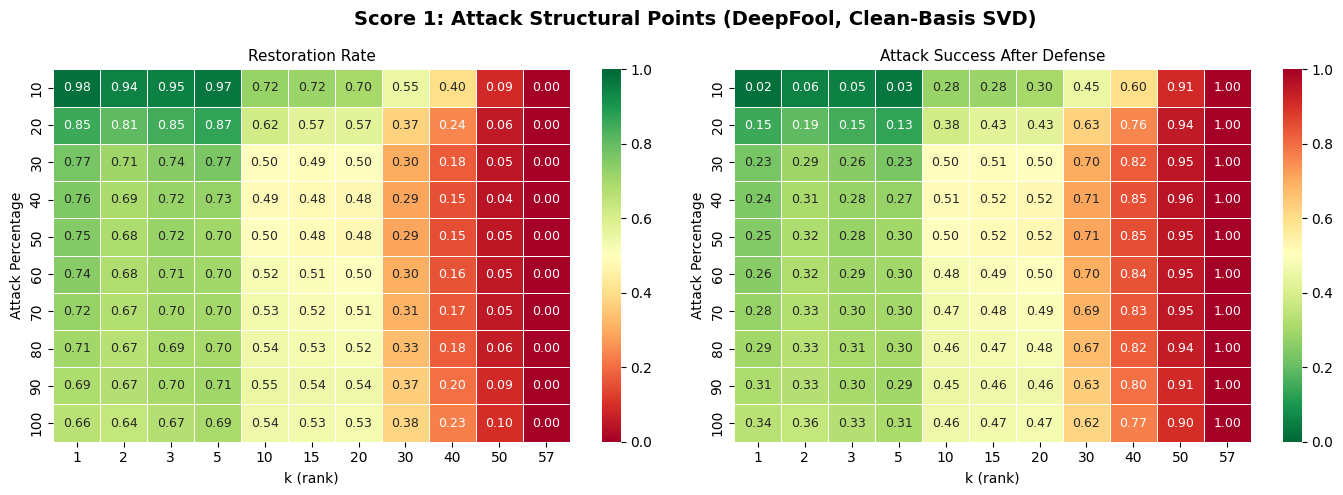

Saved vaccination_clean_score1_noisy.png


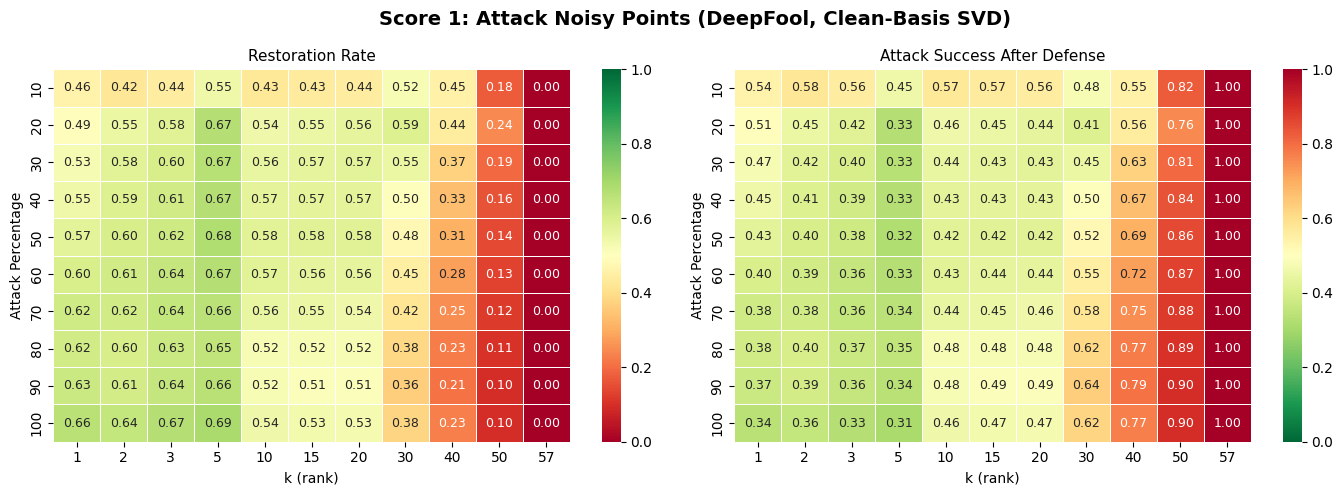

Saved vaccination_clean_score2_structural.png


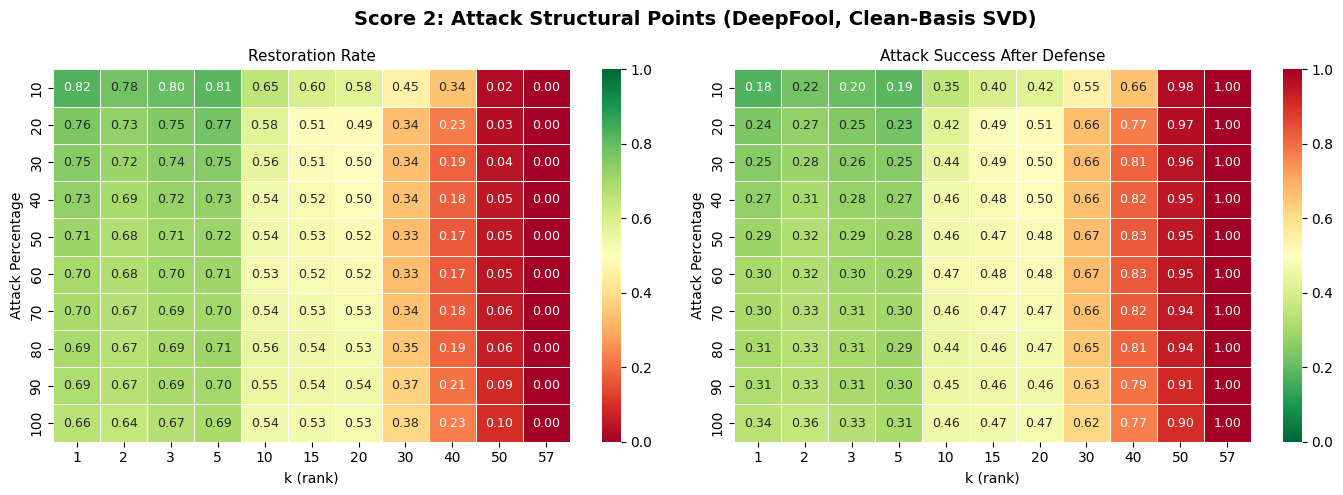

Saved vaccination_clean_score2_noisy.png


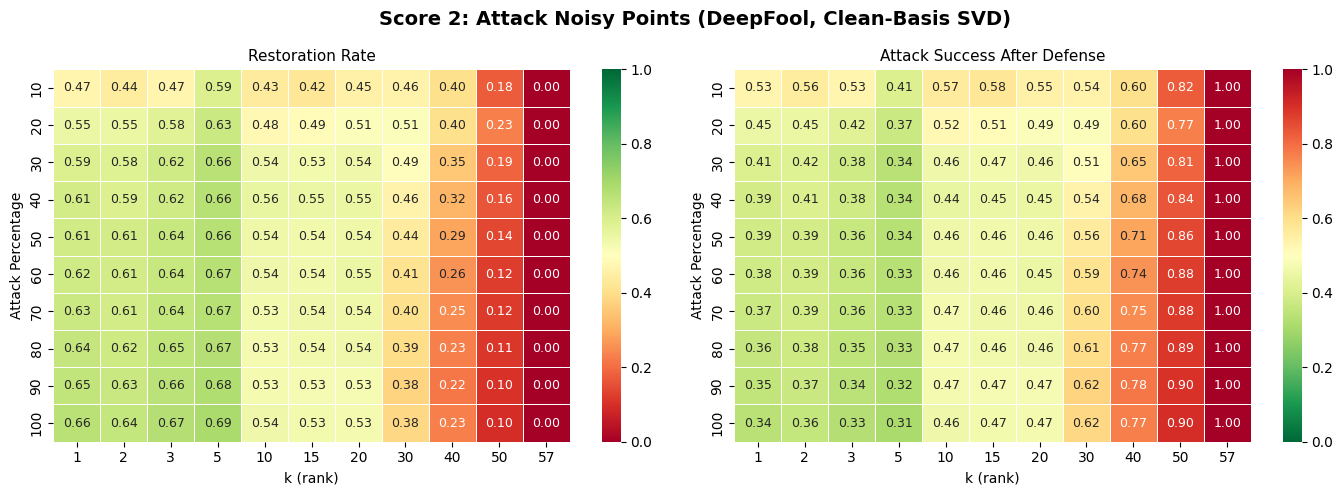

In [12]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'{score_name}: Attack {tier_name.capitalize()} Points (DeepFool, Clean-Basis SVD)',
        fontsize=14, fontweight='bold',
    )

    pivot_rest = sub.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_rest = pivot_rest.sort_index(ascending=True)
    pivot_asr = sub.pivot(index='attack_pct', columns='k', values='asr_after')
    pivot_asr = pivot_asr.sort_index(ascending=True)

    sns.heatmap(
        pivot_rest, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=1, linewidths=0.5,
        annot_kws={'size': 9},
    )
    axes[0].set_title('Restoration Rate', fontsize=11)
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage')

    sns.heatmap(
        pivot_asr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0, vmax=1, linewidths=0.5,
        annot_kws={'size': 9},
    )
    axes[1].set_title('Attack Success After Defense', fontsize=11)
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_clean_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)


## 6. Save Summary

In [13]:
summary = {
    'config': {
        'attack_method': 'DeepFool',
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_train': int(X_train.shape[0]),
        'n_test': int(n_test), 'n_correct': int(n_correct),
        'svd_basis': 'X_train (clean)',
    },
    'attack_success': int(attack_success[correct_indices].sum()),
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')


All results saved to targeted_vaccination_clean_basis_results_deepfool
  summary.json                                  (0.5 KB)
  vaccination_clean_score1_noisy.png            (216.2 KB)
  vaccination_clean_score1_structural.png       (218.9 KB)
  vaccination_clean_score2_noisy.png            (221.1 KB)
  vaccination_clean_score2_structural.png       (223.2 KB)
  vaccination_sweep.csv                         (28.7 KB)
